![title](moto.png)

## Links to the data we use in this research

- World Bank Open Data, Labor Force Participation Rate by Gender : https://genderdata.worldbank.org/en/indicator/sl-tlf-acti-zs?utm_source=chatgpt.com
- World Bank Open Data, Ration of female to male labour forcce participation rate : https://data.worldbank.org/indicator/SL.TLF.CACT.FM.ZS?end=2023&most_recent_value_desc=true&start=2023&type=shaded&utm_source=chatgpt.com&view=map&year=2023
- World Bank Open Data, Population number : https://genderdata.worldbank.org/en/indicator/sp-pop?utm_source=chatgpt.com
- Eurostat, Population by sex, age, citizenship and labour status : https://ec.europa.eu/eurostat/databrowser/view/lfsa_pganws/default/table?lang=en&category=mi.mii.mii_emp
- US Bureau of labor statistics, Labor force characteristics by race and ethnicity, 2021 : https://www.bls.gov/opub/reports/race-and-ethnicity/2021/

## Code work ahead!
yeah, I sure hope it does

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# let's load data from the first link
df_labour = pd.read_csv("data/labor-force-participation-rate-of-population/Labor force participation rate (% of population) .csv")

df_labour.head()

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2023,64.487,"female, Modeled, 15+"
1,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2022,64.218,"female, Modeled, 15+"
2,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2021,64.059,"female, Modeled, 15+"
3,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2020,63.535,"female, Modeled, 15+"
4,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2019,64.309,"female, Modeled, 15+"


In [4]:
# let's load data from the second link
df_f2mratio = pd.read_csv("data/API_SL/Ratio of female to male labor force participation rate.csv",sep=';')

df_f2mratio.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
230,Samoa,WSM,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,63.060467,62.973549,62.829590,62.576572,62.419951,62.106370,...,61.124507,61.211156,61.4380928347707,61.452547,60.540159,59.805875,58.949143,58.236856,55.114209,55.720027
231,"Yemen, Rep.",YEM,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,22.151294,22.357774,22.723393,22.774270,23.072344,24.411626,...,8.912051,8.900398,8.7353633945063,8.599781,8.506404,8.425676,8.418072,8.446326,8.219246,8.135934
232,South Africa,ZAF,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,67.374116,67.602412,67.552620,67.895547,67.966589,67.634628,...,78.111690,78.409126,78.0393593795325,79.307521,79.213294,79.762982,79.457130,79.476542,80.078402,81.971504
233,Zambia,ZMB,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,73.976978,74.083675,74.169141,74.226477,74.237357,74.207447,...,78.090015,78.530569,79.0270829214884,79.577142,80.161109,77.645132,80.522748,81.623390,82.655109,82.842045
234,Zimbabwe,ZWE,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,78.554852,79.180321,78.967844,78.646904,79.157296,79.983468,...,82.510538,82.656156,82.9626279653003,83.391599,83.896312,84.432795,83.771955,83.832060,83.350533,83.670293


In [5]:
# let's load data from the third link
df_population = pd.read_csv("data/population-number/Population (number).csv")
df_population.head()

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2023,379025748.0,"female, All ages"
1,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2022,369655503.0,"female, All ages"
2,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2021,360249371.0,"female, All ages"
3,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2020,350869705.0,"female, All ages"
4,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2019,341569862.0,"female, All ages"


In [6]:
# let's load data from the fourth link
df_EU = pd.read_csv('data/EU-employment of migrats.tsv',sep='\t')
df_EU_metadata = df_EU[df_EU.columns[0]].str.split(',', expand=True)
df_EU_metadata.columns = df_EU.columns[0].split(',')
df_EU = df_EU.drop(df_EU.columns[0], axis=1)
df_EU.columns = df_EU.columns.str.strip()
df_EU = df_EU_metadata.join(df_EU)
df_EU = df_EU.replace({r'.*:.*': np.nan}, regex=True)
df_EU = df_EU.replace({r'(\d+)\s+\D+': r'\1'}, regex=True)
df_EU

,freq,unit,sex,citizen,age,wstatus,geo\TIME_PERIOD,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,AT,NaN,NaN,NaN,...,3.5,NaN,3.2,NaN,3.3,4.3,4.2,4.2,5.7,5.6
1,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,BE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.3,NaN,NaN,NaN,NaN
2,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,CH,NaN,10.3,15.1,...,8.5,9.3,10.2,11.5,12.9,11.2,12.2,11.1,9.7,11.9
3,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,CY,NaN,NaN,NaN,...,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,0.6
4,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,CZ,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122320,A,THS_PER,T,TOTAL,Y_GE75,POP,SI,NaN,78.3,87.2,...,170.0,172.6,176.9,179.7,189.0,194.2,187.6,168.5,169.7,175.5
122321,A,THS_PER,T,TOTAL,Y_GE75,POP,SK,NaN,NaN,NaN,...,299.7,305.6,312.3,320.3,327.3,334.3,344.5,326.3,323.6,334.9
122322,A,THS_PER,T,TOTAL,Y_GE75,POP,TR,NaN,NaN,NaN,...,2469.3,2526.4,2642.1,2587.2,2668.6,2736.2,2846.2,2922.8,2970.6,3060.2
122323,A,THS_PER,T,TOTAL,Y_GE75,POP,UK,3660.3,3759.8,3834.4,...,4865.6,4929.1,4972.0,5053.7,5180.7,5337.8,NaN,NaN,NaN,NaN


In [7]:
# let's load data from the fifth link that was parsed
df_US = pd.read_csv('data/Labor force characteristics by race and ethnicity.csv')
df_US.tail()

,Year,"Total, total","Total, male","Total, female","White, total","White, male","White, female","Black or African American, total","Black or African American, male","Black or African American, female","Asian, total","Asian, male","Asian, female","Hispanic or Latino ethnicity, total","Hispanic or Latino ethnicity, male","Hispanic or Latino ethnicity, female"
45,2017,62.9,69.1,57.0,62.8,69.5,56.4,62.3,64.6,60.3,63.6,71.9,56.4,66.1,75.8,56.4
46,2018,62.9,69.1,57.1,62.8,69.5,56.4,62.3,64.8,60.2,63.5,71.6,56.4,66.3,75.7,57.0
47,2019,63.1,69.2,57.4,63.0,69.6,56.8,62.5,64.8,60.5,64.0,71.8,57.1,66.8,75.9,57.7
48,2020,61.7,67.7,56.2,61.8,68.2,55.7,60.5,62.6,58.8,62.7,70.9,55.5,65.6,74.9,56.4
49,2021,61.7,67.6,56.1,61.5,67.9,55.4,60.9,63.5,58.8,63.8,71.8,56.8,65.5,75.4,55.8


## let's check if countries match in one and the other table(it's the same number of them and every is represented in both data frames)

In [8]:
set1 = set(df_population['Country Code'])
set2 = set(df_labour['Country Code'])

diff_population = set1 - set2
diff_labour = set2 - set1

diff_population # it shows countries that have data about population, but no about labour force participation


{'MAF', 'SXM'}

## Let's analyse some data from EU

In [92]:
df_EU_workers = df_EU[(df_EU['citizen'] == 'FOR') & (df_EU['wstatus']=='EMP') & (df_EU['geo\TIME_PERIOD']=='EU27_2020') & (df_EU['sex']=='T') & (df_EU['age']=='Y15-59')]
df_EU_workers

,freq,unit,sex,citizen,age,wstatus,geo\TIME_PERIOD,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
88000,A,THS_PER,T,FOR,Y15-59,EMP,EU27_2020,NaN,NaN,NaN,...,11755.4,12235.7,12911.8,13582.2,14254.9,14995.3,14477.7,14927.7,16449.9,17787.1


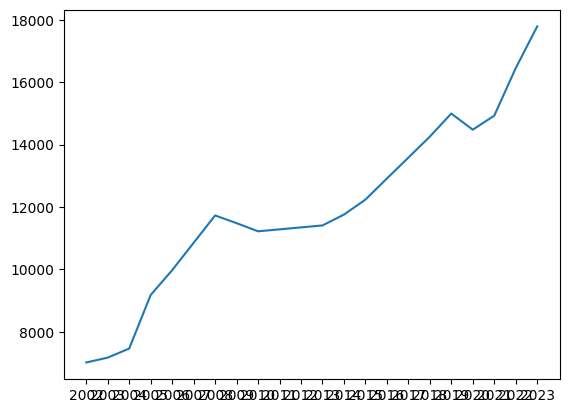

In [98]:
#this graph shows number of foreigners who work in EU(in thousands) 
x = df_EU_workers.columns[14:]
y = df_EU_workers.iloc[0, 14:].values.astype(float)

plt.plot(x,y)